# Lab 5 — Decision Tree and SVM Regression on the Abalone Dataset

The goal of this lab is to apply supervised regression techniques to predict the **age** (number of rings) of abalones from physical measurements. We will:

1. Perform exploratory data analysis (EDA) on the dataset
2. Preprocess the data (encode categorical features)
3. Train a **Decision Tree Regressor** with default hyperparameters
4. Evaluate performance and compare predictions against ground truth
5. Fine-tune hyperparameters via **5-fold cross-validation**
6. Visualise and interpret the optimal decision tree
7. Train an **SVM Regressor** and compare results between both models

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.tree import DecisionTreeRegressor, export_text, plot_tree
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline

import warnings
warnings.filterwarnings("ignore")

# ── reproducibility ────────────────────────────────────────────────────────────
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ── plot style ─────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({"figure.dpi": 110, "axes.titlesize": 13, "axes.labelsize": 11})

print("All libraries imported successfully.")

All libraries imported successfully.


## Task 1 — Load Data and Exploratory Data Analysis

The **Abalone** dataset (UCI Machine Learning Repository) contains **4177 instances** and **8 features** measured from physical specimens. The regression target is `Rings`, which is directly related to age: **age ≈ Rings + 1.5 years**.

| Feature | Description |
|---|---|
| Sex | M (male), F (female), I (infant) |
| Length | Longest shell measurement (mm) |
| Diameter | Perpendicular to length (mm) |
| Height | With meat in shell (mm) |
| Whole weight | Whole abalone (g) |
| Shucked weight | Weight of meat (g) |
| Viscera weight | Gut weight after bleeding (g) |
| Shell weight | After being dried (g) |
| **Rings** | **Target — number of rings** |

In [3]:
COLUMN_NAMES = [
    "Sex", "Length", "Diameter", "Height",
    "Whole_weight", "Shucked_weight", "Viscera_weight",
    "Shell_weight", "Rings"
]

df = pd.read_csv("abalone.data", header=None, names=COLUMN_NAMES)

print(f"Dataset shape : {df.shape}")
print(f"\nData types:\n{df.dtypes}")
print(f"\nFirst 5 rows:")
df.head()

Dataset shape : (4177, 9)

Data types:
Sex                object
Length            float64
Diameter          float64
Height            float64
Whole_weight      float64
Shucked_weight    float64
Viscera_weight    float64
Shell_weight      float64
Rings               int64
dtype: object

First 5 rows:


,Sex,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
0,M,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15
1,M,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7
2,F,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9
3,M,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10
4,I,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7


In [4]:
print("=== Missing values ===")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")
print("\n=== Summary statistics ===")
df.describe()

=== Missing values ===
Sex               0
Length            0
Diameter          0
Height            0
Whole_weight      0
Shucked_weight    0
Viscera_weight    0
Shell_weight      0
Rings             0
dtype: int64

Total missing: 0

=== Summary statistics ===


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings
count,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000,4177.000000
mean,0.523992,0.407881,0.139516,0.828742,0.359367,0.180594,0.238831,9.933684
std,0.120093,0.099240,0.041827,0.490389,0.221963,0.109614,0.139203,3.224169
min,0.075000,0.055000,0.000000,0.002000,0.001000,0.000500,0.001500,1.000000
25%,0.450000,0.350000,0.115000,0.441500,0.186000,0.093500,0.130000,8.000000
50%,0.545000,0.425000,0.140000,0.799500,0.336000,0.171000,0.234000,9.000000
75%,0.615000,0.480000,0.165000,1.153000,0.502000,0.253000,0.329000,11.000000
max,0.815000,0.650000,1.130000,2.825500,1.488000,0.760000,1.005000,29.000000


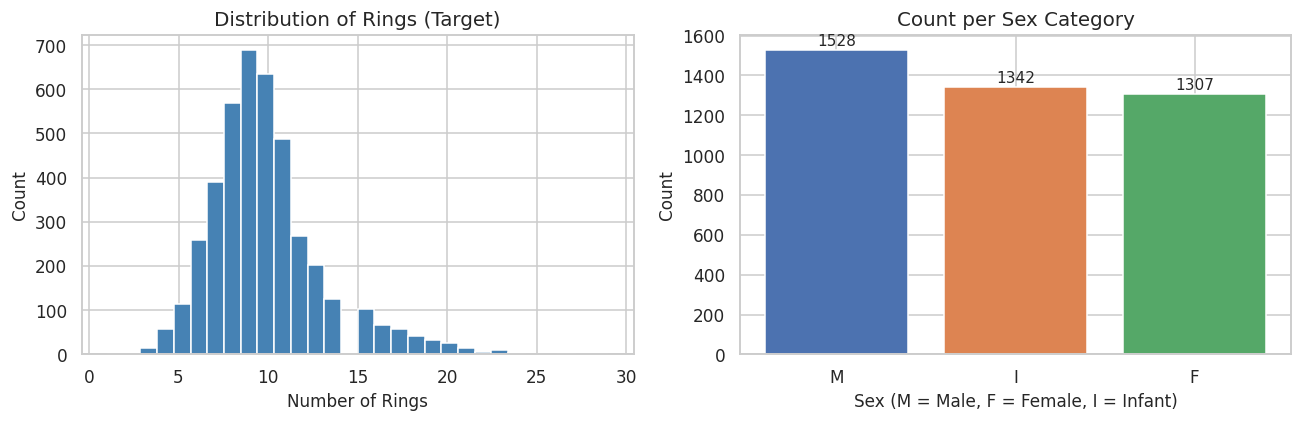

In [5]:
# ── Distribution of the target variable ───────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df["Rings"], bins=30, color="steelblue", edgecolor="white")
axes[0].set_title("Distribution of Rings (Target)")
axes[0].set_xlabel("Number of Rings")
axes[0].set_ylabel("Count")

# ── Class counts for the Sex feature ─────────────────────────────────────────
sex_counts = df["Sex"].value_counts()
axes[1].bar(sex_counts.index, sex_counts.values,
            color=["#4C72B0", "#DD8452", "#55A868"], edgecolor="white")
axes[1].set_title("Count per Sex Category")
axes[1].set_xlabel("Sex (M = Male, F = Female, I = Infant)")
axes[1].set_ylabel("Count")
for i, v in enumerate(sex_counts.values):
    axes[1].text(i, v + 20, str(v), ha="center", fontsize=10)

plt.tight_layout()
plt.show()

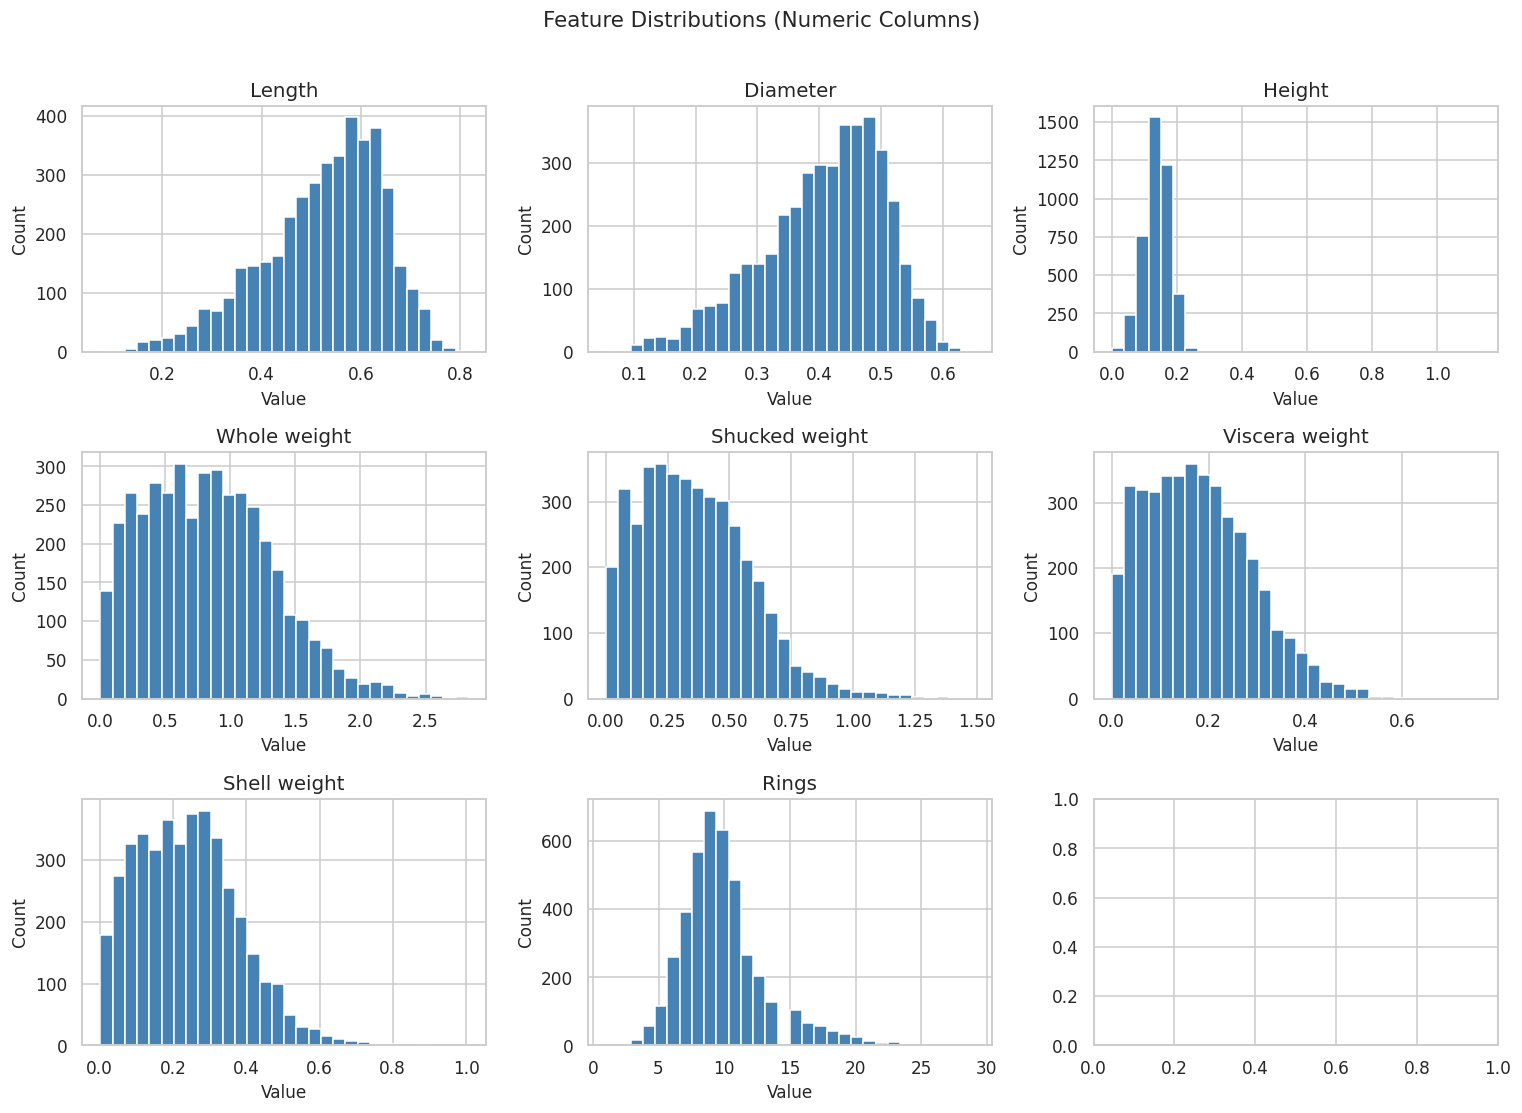

In [6]:
# ── Histograms for all numeric features ───────────────────────────────────────
numeric_cols = [c for c in df.columns if c != "Sex"]
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, color="steelblue", edgecolor="white")
    axes[i].set_title(col.replace("_", " "))
    axes[i].set_xlabel("Value")
    axes[i].set_ylabel("Count")

plt.suptitle("Feature Distributions (Numeric Columns)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

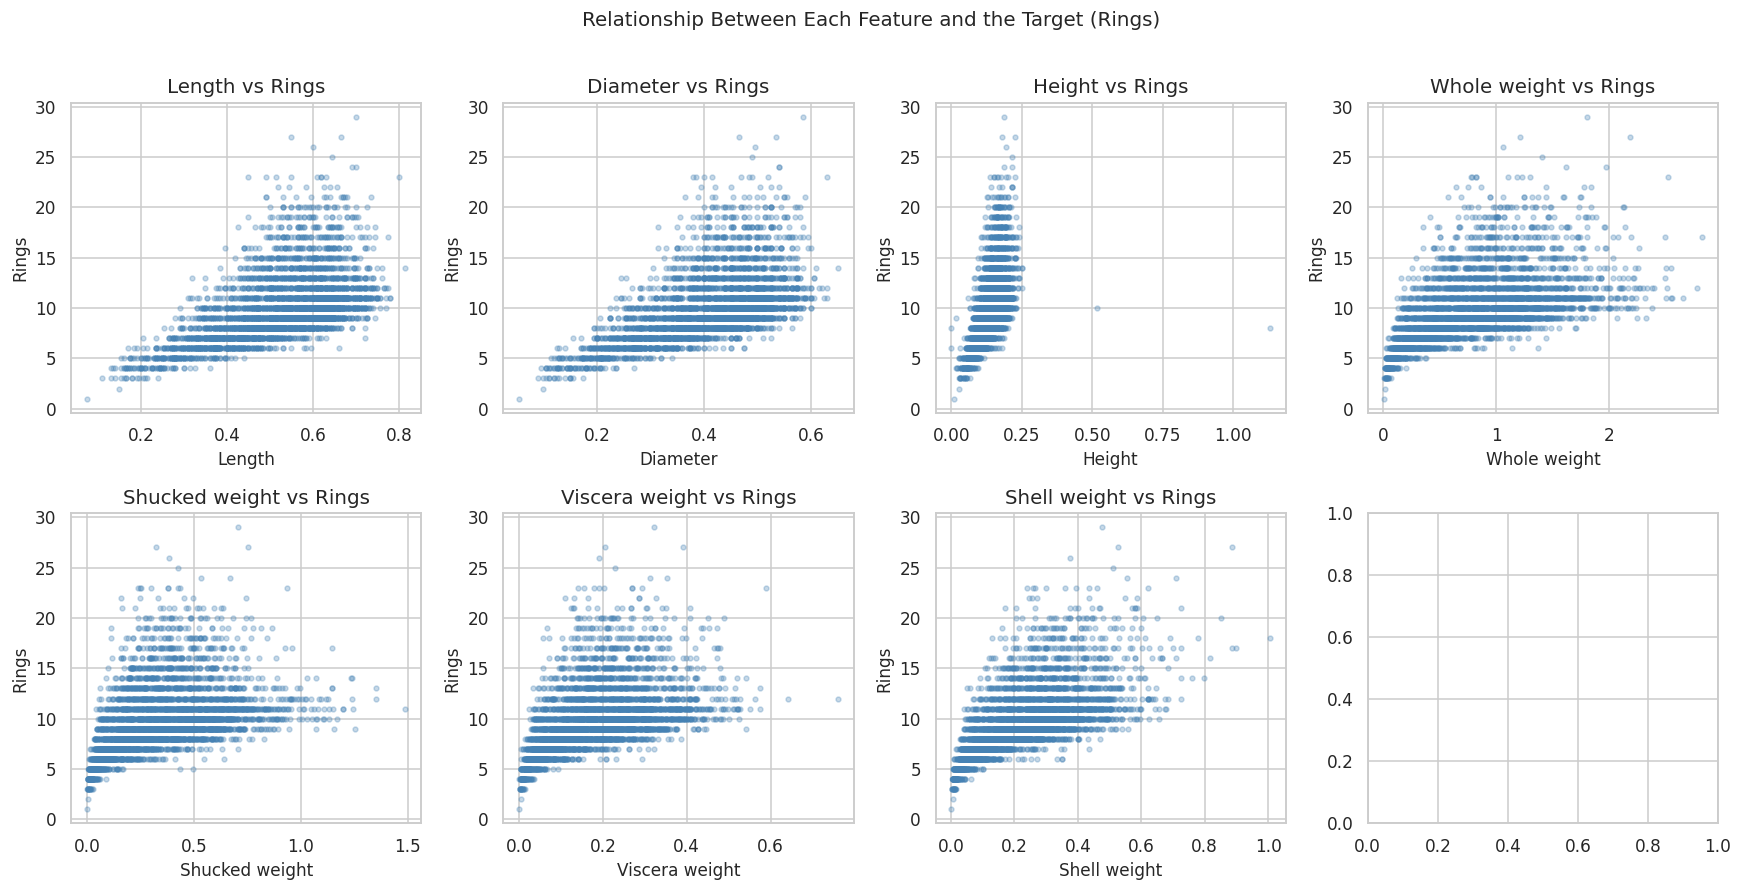

In [7]:
# ── Scatter plots: each feature vs Rings ──────────────────────────────────────
feature_cols = [c for c in numeric_cols if c != "Rings"]
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].scatter(df[col], df["Rings"], alpha=0.3, s=10, color="steelblue")
    axes[i].set_xlabel(col.replace("_", " "))
    axes[i].set_ylabel("Rings")
    axes[i].set_title(f"{col.replace('_', ' ')} vs Rings")

plt.suptitle("Relationship Between Each Feature and the Target (Rings)", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

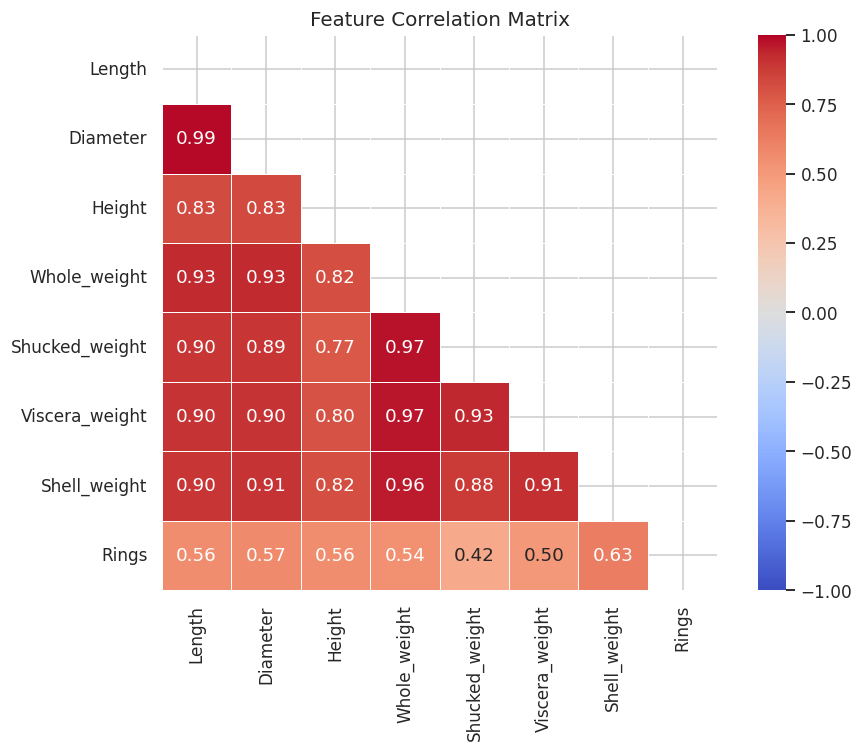

In [8]:
# ── Correlation heatmap (numeric features only) ────────────────────────────────
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(9, 7))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax)
ax.set_title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

### EDA Observations

- **No missing values** — the dataset is clean and ready for modelling.
- **Rings** (the target) is roughly right-skewed, with most specimens having 5–15 rings; a few outliers exceed 25.
- **Physical measurements** (Length, Diameter, Height, and the weight columns) are all positively correlated with each other and show a moderate positive correlation with Rings (~0.5–0.6), though the relationship is nonlinear.
- **Shell weight** has the highest individual correlation with Rings (~0.63), suggesting it is an important predictor.
- **Infant (I)** specimens tend to have fewer rings, as expected from biology.
- The high multicollinearity among the weight features (all ~0.96+) suggests they carry largely redundant information — a Decision Tree should naturally select the most informative split at each node.

## Task 2 — Data Preprocessing

The only non-numeric column is **Sex** (M / F / I). We apply **one-hot encoding** (drop the first dummy to avoid multicollinearity) to convert it into numerical form. All other features are already continuous and need no further transformation at this stage.

In [9]:
# One-hot encode the Sex column (drop_first avoids dummy-variable trap)
df_encoded = pd.get_dummies(df, columns=["Sex"], drop_first=True)

# Rename the boolean dummy columns to clear names
df_encoded.rename(columns={"Sex_I": "Sex_I", "Sex_M": "Sex_M"}, inplace=True)

# Convert any boolean columns to int for compatibility
bool_cols = df_encoded.select_dtypes(include="bool").columns
df_encoded[bool_cols] = df_encoded[bool_cols].astype(int)

print("Shape after encoding:", df_encoded.shape)
print("Columns:", df_encoded.columns.tolist())
df_encoded.head()

Shape after encoding: (4177, 10)
Columns: ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Rings', 'Sex_I', 'Sex_M']


,Length,Diameter,Height,Whole_weight,Shucked_weight,Viscera_weight,Shell_weight,Rings,Sex_I,Sex_M
0,0.455,0.365,0.095,0.5140,0.2245,0.1010,0.150,15,0,1
1,0.350,0.265,0.090,0.2255,0.0995,0.0485,0.070,7,0,1
2,0.530,0.420,0.135,0.6770,0.2565,0.1415,0.210,9,0,0
3,0.440,0.365,0.125,0.5160,0.2155,0.1140,0.155,10,0,1
4,0.330,0.255,0.080,0.2050,0.0895,0.0395,0.055,7,1,0


## Task 3 — 85 / 15 Train–Test Split

We split the data randomly into **85 % training** and **15 % test** sets using a fixed `random_state` to ensure reproducibility.

In [10]:
X = df_encoded.drop(columns=["Rings"])
y = df_encoded["Rings"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.15, random_state=RANDOM_STATE
)

print(f"Training set : {X_train.shape[0]} samples  ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set     : {X_test.shape[0]}  samples  ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"\nFeatures used: {X.columns.tolist()}")

Training set : 3550 samples  (85.0%)
Test set     : 627  samples  (15.0%)

Features used: ['Length', 'Diameter', 'Height', 'Whole_weight', 'Shucked_weight', 'Viscera_weight', 'Shell_weight', 'Sex_I', 'Sex_M']


## Task 4 — Decision Tree Regressor (Default Hyperparameters)

We train a `DecisionTreeRegressor` with all default settings (no depth limit, minimum samples per split = 2) and then inspect the resulting tree.

In [11]:
dt_default = DecisionTreeRegressor(random_state=RANDOM_STATE)
dt_default.fit(X_train, y_train)

print(f"Tree depth  : {dt_default.get_depth()}")
print(f"Leaf nodes  : {dt_default.get_n_leaves()}")
print(f"Total nodes : {dt_default.tree_.node_count}")

Tree depth  : 25
Leaf nodes  : 2075
Total nodes : 4149


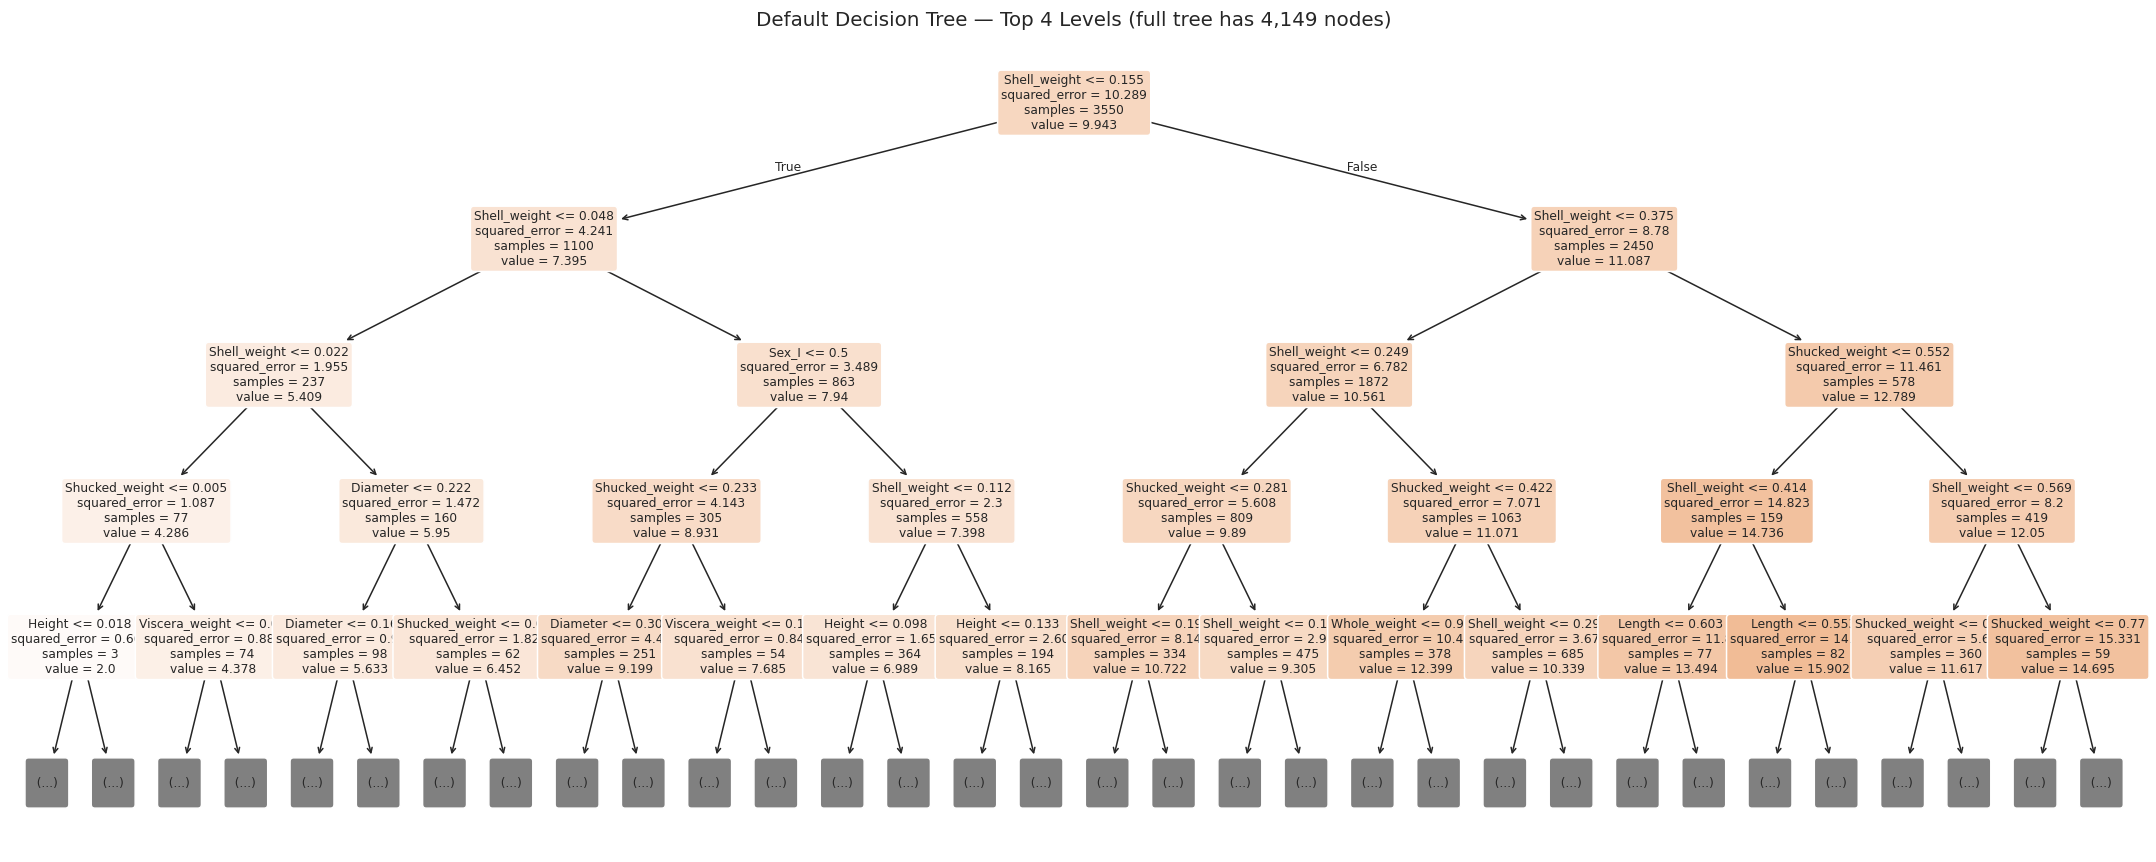

In [12]:
# Visualise the top 4 levels of the default tree (full tree is too large to render)
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_default,
    feature_names=X.columns.tolist(),
    max_depth=4,
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
)
ax.set_title("Default Decision Tree — Top 4 Levels (full tree has {:,} nodes)".format(
    dt_default.tree_.node_count))
plt.tight_layout()
plt.show()

### Is the Default Tree Reasonable?

With default settings the tree grows until every leaf is pure (or has only one sample). This results in an **extremely deep tree** (often 30+ levels) with thousands of nodes — the model effectively memorises the training data. This is a classic sign of **overfitting**: the training error will be near zero, but the test error will be substantially higher. A depth-limited tree is almost certainly more appropriate for this task.

## Task 5 — Performance Evaluation

We use three complementary metrics:

| Metric | Formula | Interpretation |
|---|---|---|
| **RMSE** | $\sqrt{\frac{1}{n}\sum(y_i - \hat{y}_i)^2}$ | Same unit as target; penalises large errors |
| **MAE** | $\frac{1}{n}\sum\|y_i - \hat{y}_i\|$ | Robust to outliers |
| **R²** | $1 - \frac{SS_{res}}{SS_{tot}}$ | Proportion of variance explained (1 = perfect) |

In [13]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te, label="Model"):
    """Return a summary DataFrame with train/test RMSE, MAE, and R²."""
    results = {}
    for split, X_, y_ in [("Train", X_tr, y_tr), ("Test", X_te, y_te)]:
        preds = model.predict(X_)
        results[split] = {
            "RMSE": np.sqrt(mean_squared_error(y_, preds)),
            "MAE" : mean_absolute_error(y_, preds),
            "R²"  : r2_score(y_, preds),
        }
    df_res = pd.DataFrame(results).T.round(4)
    print(f"\n{'='*40}")
    print(f"  {label}")
    print(f"{'='*40}")
    print(df_res.to_string())
    return df_res

perf_default = evaluate_model(dt_default, X_train, y_train, X_test, y_test,
                               "Decision Tree — Default")


  Decision Tree — Default
         RMSE     MAE      R²
Train  0.0000  0.0000  1.0000
Test   3.1094  2.0702  0.1195


## Task 6 — Predictions vs True Values (Default Tree)

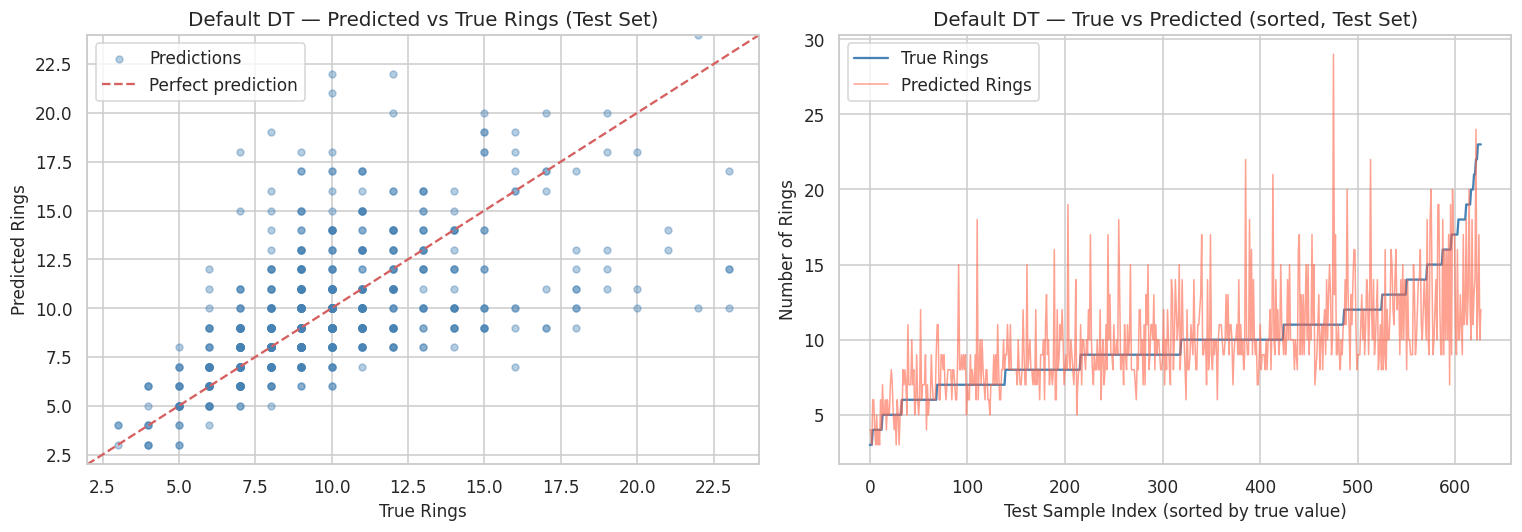

In [14]:
y_pred_default = dt_default.predict(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Scatter: predicted vs true ─────────────────────────────────────────────────
lims = [y_test.min() - 1, y_test.max() + 1]
axes[0].scatter(y_test, y_pred_default, alpha=0.4, s=20, color="steelblue", label="Predictions")
axes[0].plot(lims, lims, "r--", linewidth=1.5, label="Perfect prediction")
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("True Rings")
axes[0].set_ylabel("Predicted Rings")
axes[0].set_title("Default DT — Predicted vs True Rings (Test Set)")
axes[0].legend()

# ── Sorted predictions overlay ────────────────────────────────────────────────
sorted_idx = np.argsort(y_test.values)
axes[1].plot(range(len(sorted_idx)), y_test.values[sorted_idx],
             color="steelblue", label="True Rings", linewidth=1.5)
axes[1].plot(range(len(sorted_idx)), y_pred_default[sorted_idx],
             color="tomato", alpha=0.6, label="Predicted Rings", linewidth=1)
axes[1].set_xlabel("Test Sample Index (sorted by true value)")
axes[1].set_ylabel("Number of Rings")
axes[1].set_title("Default DT — True vs Predicted (sorted, Test Set)")
axes[1].legend()

plt.tight_layout()
plt.show()

### Comments on the Default Tree Results

The scatter plot shows that predictions are largely discrete (each leaf predicts the mean of its training samples), leading to a "banded" pattern. The model clearly **overfits**: training RMSE is essentially 0 while test RMSE is considerably higher. The sorted-value plot confirms the model struggles to generalise — predictions are noisy and only broadly follow the true trend. Hyperparameter tuning is needed.

## Task 7 — Hyperparameter Tuning with 5-Fold Cross-Validation

We search over two key hyperparameters:
- **`max_depth`** — limits the depth of the tree to prevent overfitting
- **`min_samples_split`** — the minimum number of samples required to split an internal node

We use `GridSearchCV` with 5-fold CV and **negative RMSE** as the scoring metric.

In [15]:
param_grid = {
    "max_depth"        : [3, 5, 7, 9, 11, 13, 15, None],
    "min_samples_split": [2, 5, 10, 20, 50],
}

grid_search = GridSearchCV(
    estimator  = DecisionTreeRegressor(random_state=RANDOM_STATE),
    param_grid = param_grid,
    cv         = 5,
    scoring    = "neg_root_mean_squared_error",
    n_jobs     = -1,
    refit      = True,
)

grid_search.fit(X_train, y_train)

print("Best parameters :", grid_search.best_params_)
print(f"Best CV RMSE    : {-grid_search.best_score_:.4f}")

Best parameters : {'max_depth': 5, 'min_samples_split': 2}
Best CV RMSE    : 2.3345


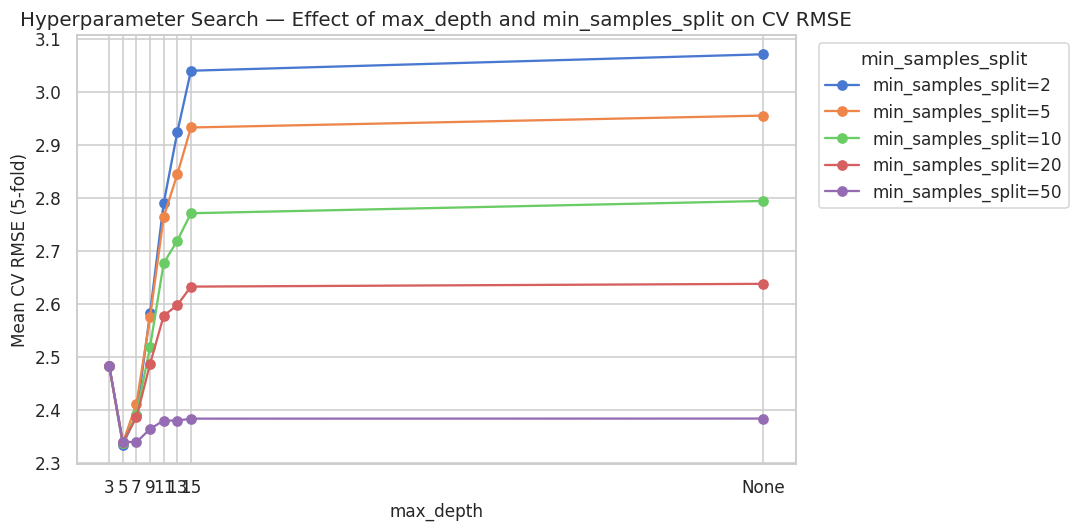

In [16]:
# ── Effect of max_depth on CV RMSE (averaged across min_samples_split) ─────────
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results["mean_rmse"] = -cv_results["mean_test_score"]

# Replace None with a numeric sentinel for plotting
depth_vals = cv_results["param_max_depth"].fillna(99).astype(int)
cv_results = cv_results.assign(depth_num=depth_vals)

pivot = cv_results.pivot_table(
    index="depth_num",
    columns="param_min_samples_split",
    values="mean_rmse"
)

fig, ax = plt.subplots(figsize=(10, 5))
for col in pivot.columns:
    ax.plot(pivot.index, pivot[col], marker="o", label=f"min_samples_split={col}")

ax.set_xticks(pivot.index)
ax.set_xticklabels([str(v) if v != 99 else "None" for v in pivot.index])
ax.set_xlabel("max_depth")
ax.set_ylabel("Mean CV RMSE (5-fold)")
ax.set_title("Hyperparameter Search — Effect of max_depth and min_samples_split on CV RMSE")
ax.legend(title="min_samples_split", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

In [17]:
# ── Re-train with best parameters ─────────────────────────────────────────────
dt_tuned = grid_search.best_estimator_  # already refitted on full training data

print(f"Tuned tree depth : {dt_tuned.get_depth()}")
print(f"Tuned leaf nodes : {dt_tuned.get_n_leaves()}")

print("\n── Default DT ──────────────────────────────")
perf_default2 = evaluate_model(dt_default, X_train, y_train, X_test, y_test,
                                "Decision Tree — Default")

print("\n── Tuned DT ────────────────────────────────")
perf_tuned = evaluate_model(dt_tuned, X_train, y_train, X_test, y_test,
                             "Decision Tree — Tuned")

Tuned tree depth : 5
Tuned leaf nodes : 32

── Default DT ──────────────────────────────

  Decision Tree — Default
         RMSE     MAE      R²
Train  0.0000  0.0000  1.0000
Test   3.1094  2.0702  0.1195

── Tuned DT ────────────────────────────────

  Decision Tree — Tuned
         RMSE     MAE      R²
Train  2.1496  1.5275  0.5509
Test   2.3942  1.6753  0.4780


### What Changed After Tuning?

- **Training RMSE increases** slightly for the tuned model — a constrained tree cannot perfectly memorise the training data.
- **Test RMSE decreases** — the tuned tree generalises better because over-fitting has been reduced by limiting depth and requiring more samples per split.
- **R² on the test set improves**, confirming better generalisation.
- The much smaller tree (fewer nodes/leaves) is also far more interpretable.

This illustrates the classic **bias–variance trade-off**: the default tree has very low bias but extremely high variance, whereas the tuned tree achieves a better balance.

## Task 8 — Comparing Both Models: Predictions vs True Values

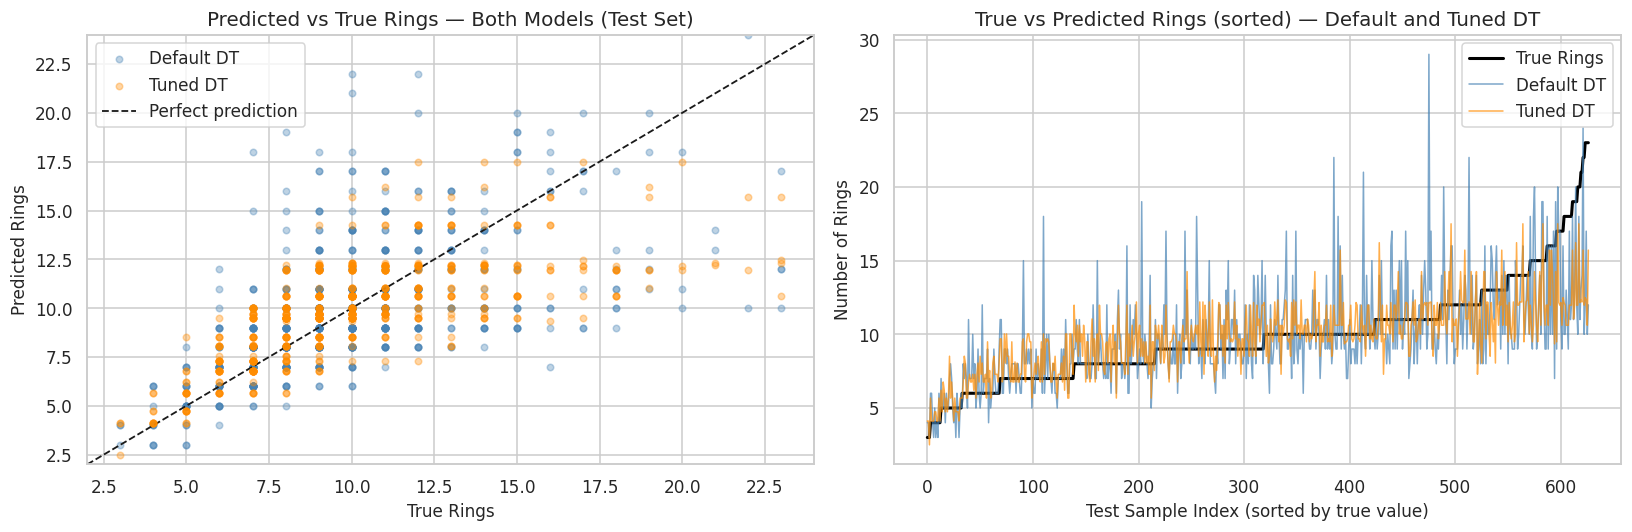

In [18]:
y_pred_tuned = dt_tuned.predict(X_test)

sorted_idx = np.argsort(y_test.values)
x_axis     = np.arange(len(sorted_idx))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Scatter: predicted vs true for both models ────────────────────────────────
lims = [y_test.min() - 1, y_test.max() + 1]
axes[0].scatter(y_test, y_pred_default, alpha=0.35, s=18, color="steelblue",
                label="Default DT", zorder=2)
axes[0].scatter(y_test, y_pred_tuned,   alpha=0.35, s=18, color="darkorange",
                label="Tuned DT",   zorder=3)
axes[0].plot(lims, lims, "k--", linewidth=1.2, label="Perfect prediction")
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("True Rings")
axes[0].set_ylabel("Predicted Rings")
axes[0].set_title("Predicted vs True Rings — Both Models (Test Set)")
axes[0].legend()

# ── Sorted-value line plot ────────────────────────────────────────────────────
axes[1].plot(x_axis, y_test.values[sorted_idx],
             color="black", linewidth=2, label="True Rings")
axes[1].plot(x_axis, y_pred_default[sorted_idx],
             color="steelblue", alpha=0.7, linewidth=1, label="Default DT")
axes[1].plot(x_axis, y_pred_tuned[sorted_idx],
             color="darkorange", alpha=0.7, linewidth=1, label="Tuned DT")
axes[1].set_xlabel("Test Sample Index (sorted by true value)")
axes[1].set_ylabel("Number of Rings")
axes[1].set_title("True vs Predicted Rings (sorted) — Default and Tuned DT")
axes[1].legend()

plt.tight_layout()
plt.show()

### Comments on the Comparison Plot

Both models predict discrete values (means of leaf clusters), but the **tuned model clusters are fewer and broader**, reflecting the shallower tree depth. In the sorted-value plot the tuned model's predictions track the true trend more smoothly with less erratic jumping — the reduced variance from depth limiting is visible. The default model hugs the training data too tightly, resulting in larger errors on unseen test samples, particularly for high ring counts where training examples are sparse.

## Task 9 — Visualise and Interpret the Fine-Tuned Decision Tree

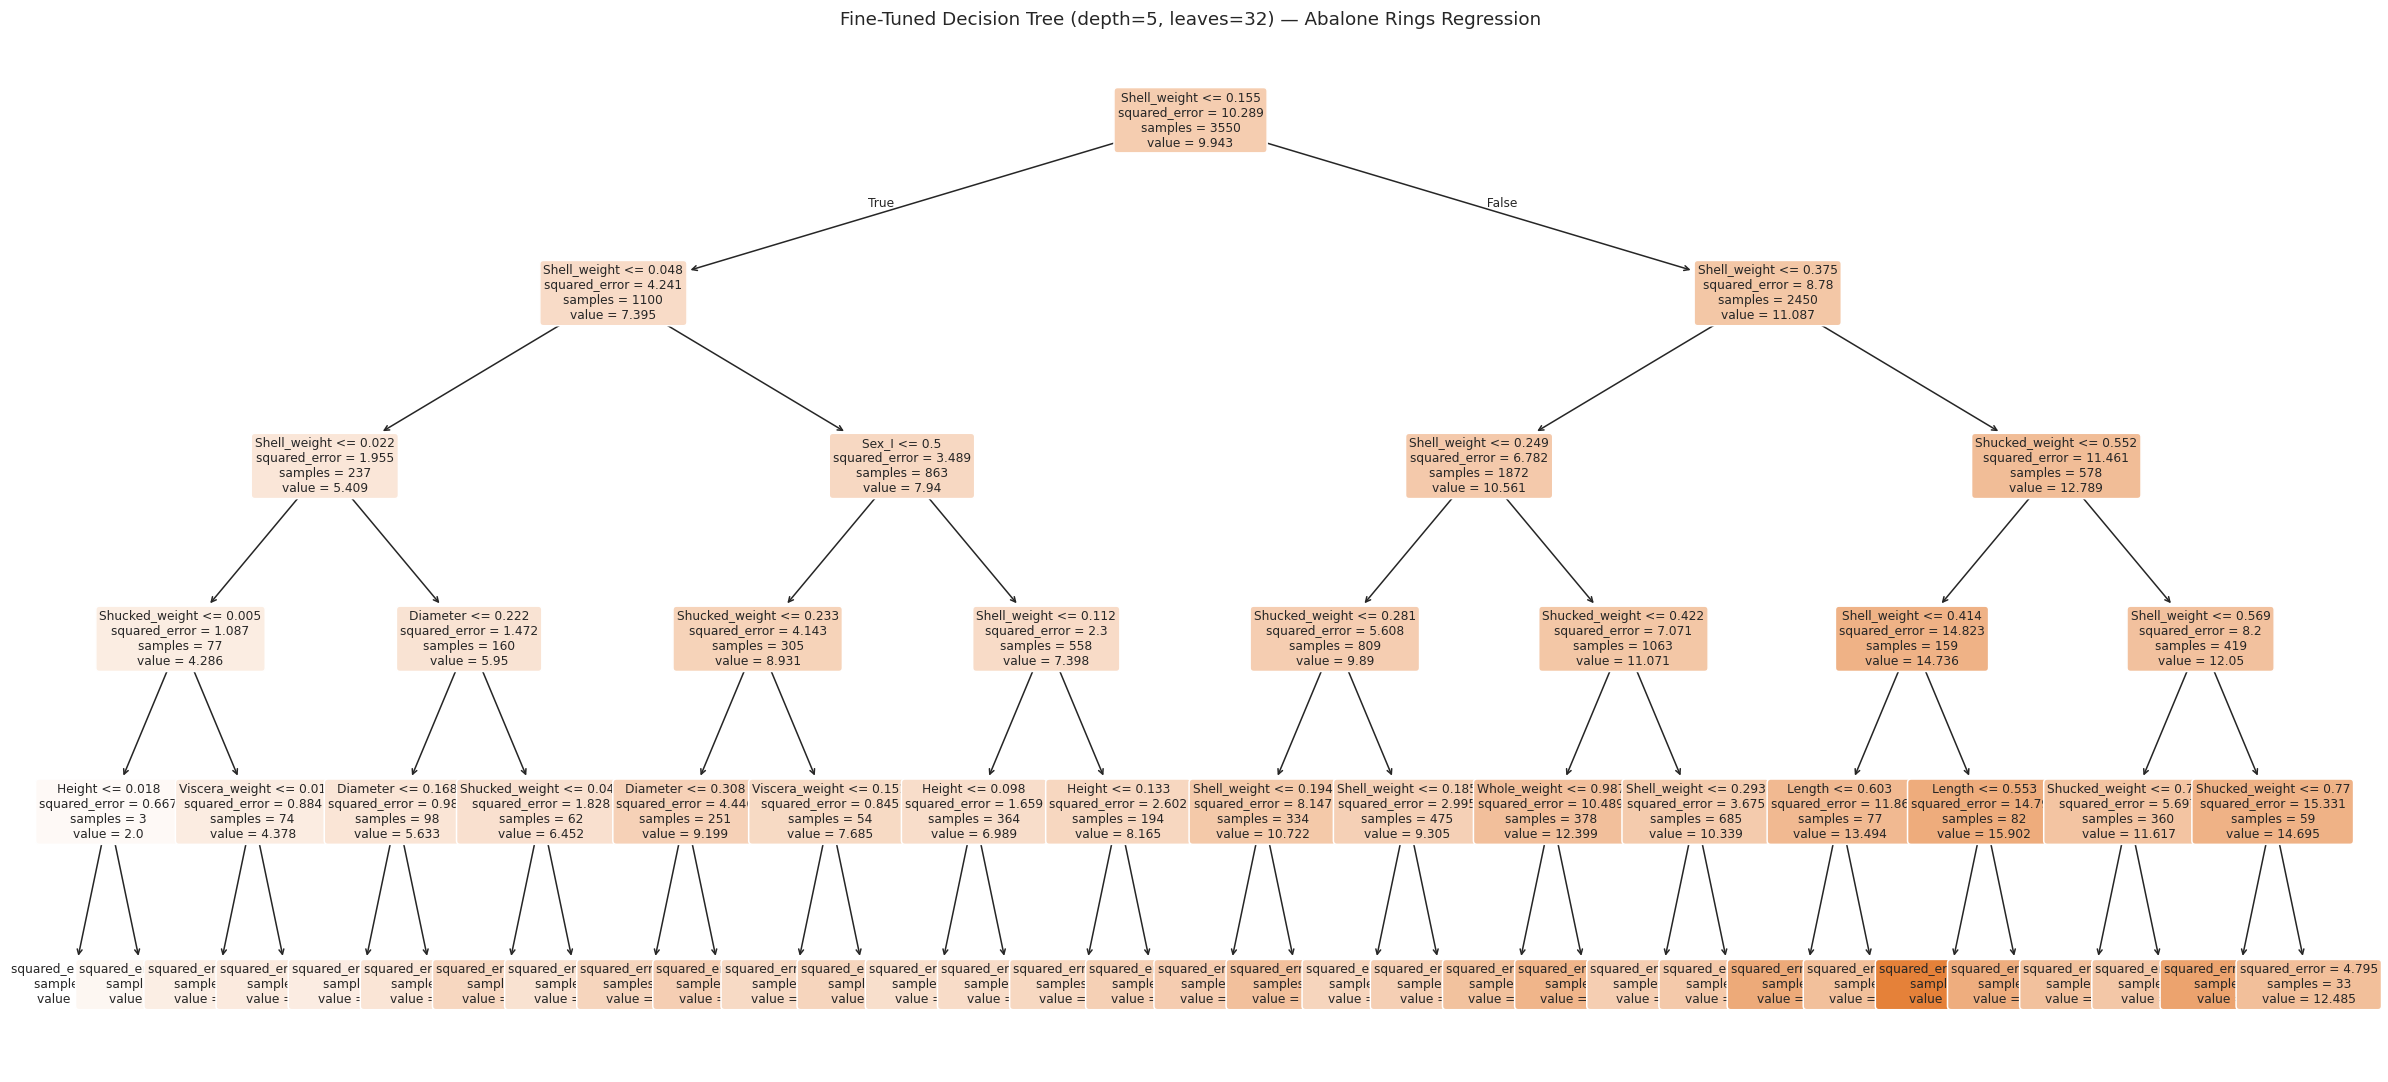

In [19]:
fig, ax = plt.subplots(figsize=(22, 10))
plot_tree(
    dt_tuned,
    feature_names=X.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=8,
    ax=ax,
    impurity=True,
)
ax.set_title(
    f"Fine-Tuned Decision Tree (depth={dt_tuned.get_depth()}, "
    f"leaves={dt_tuned.get_n_leaves()}) — Abalone Rings Regression",
    fontsize=12,
)
plt.tight_layout()
plt.show()

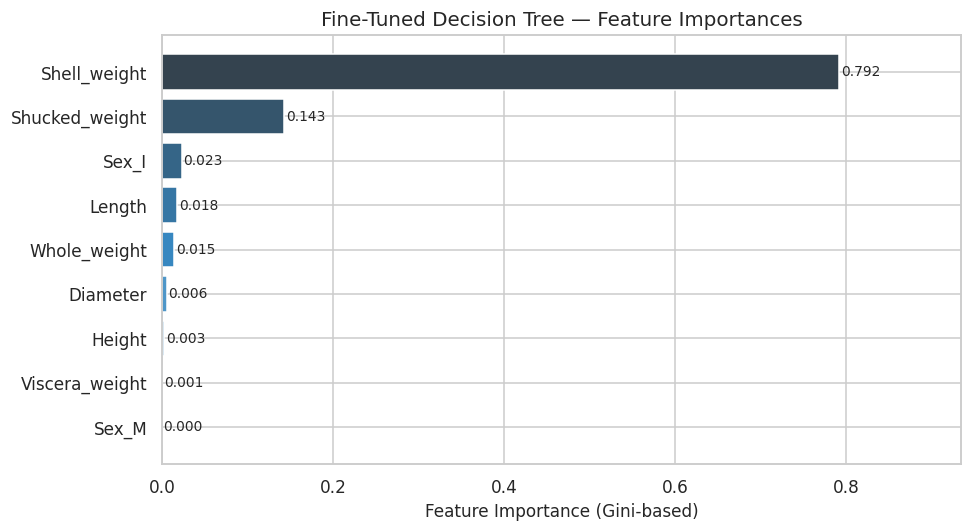


Ranked feature importances:
Shell_weight      0.792074
Shucked_weight    0.143179
Sex_I             0.023043
Length            0.017975
Whole_weight      0.014735
Diameter          0.005734
Height            0.002598
Viscera_weight    0.000660
Sex_M             0.000000


In [20]:
# ── Feature importances ────────────────────────────────────────────────────────
importances = pd.Series(dt_tuned.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
colors = sns.color_palette("Blues_d", len(importances))
bars = ax.barh(importances.index, importances.values, color=colors, edgecolor="white")

for bar, val in zip(bars, importances.values):
    ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{val:.3f}", va="center", fontsize=9)

ax.set_xlabel("Feature Importance (Gini-based)")
ax.set_title("Fine-Tuned Decision Tree — Feature Importances")
ax.set_xlim(0, importances.max() * 1.18)
plt.tight_layout()
plt.show()

print("\nRanked feature importances:")
print(importances.sort_values(ascending=False).to_string())

### Tree Interpretation

- **Shell weight** consistently appears at or near the root of the tree — it is the single most informative feature for predicting age (rings), consistent with the high correlation observed in the EDA.
- **Shucked weight** and **Whole weight** are also important, reflecting the fact that heavier abalones tend to be older, though the relationship is not perfectly linear.
- The **Sex** dummies contribute very little; while infants (I) are biologically younger, the physical measurements already capture size information, making Sex largely redundant once we condition on weight/length.
- Each internal node encodes a simple threshold rule, making the tuned tree fully interpretable and understandable by domain experts without any ML background.

## Task 10 — SVM Regressor with Hyperparameter Tuning

Support Vector Regression (SVR) is sensitive to the scale of input features, so we must **standardise** the features before training. We wrap an `StandardScaler` and `SVR` together in a `Pipeline` to prevent data leakage during cross-validation.

We tune two hyperparameters:
- **`C`** — regularisation strength (larger C → less regularisation, more flexible)
- **`epsilon`** — width of the ε-insensitive tube (errors within ε are not penalised)

In [21]:
svr_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("svr",    SVR(kernel="rbf")),
])

svr_param_grid = {
    "svr__C"      : [0.1, 1, 10, 50, 100],
    "svr__epsilon": [0.1, 0.5, 1.0],
}

svr_grid = GridSearchCV(
    estimator  = svr_pipeline,
    param_grid = svr_param_grid,
    cv         = 5,
    scoring    = "neg_root_mean_squared_error",
    n_jobs     = -1,
    refit      = True,
)

svr_grid.fit(X_train, y_train)

print("Best SVR parameters:", svr_grid.best_params_)
print(f"Best CV RMSE       : {-svr_grid.best_score_:.4f}")

Best SVR parameters: {'svr__C': 10, 'svr__epsilon': 1.0}
Best CV RMSE       : 2.1304


In [22]:
svr_best = svr_grid.best_estimator_

print("── Tuned SVR ────────────────────────────────")
perf_svr = evaluate_model(svr_best, X_train, y_train, X_test, y_test, "SVR — Tuned")

# ── Final comparison table ─────────────────────────────────────────────────────
summary = pd.DataFrame({
    "Default DT"  : perf_default.loc["Test"],
    "Tuned DT"    : perf_tuned.loc["Test"],
    "Tuned SVR"   : perf_svr.loc["Test"],
}).T.round(4)

print("\n=== Final Test-Set Comparison ===")
print(summary.to_string())

── Tuned SVR ────────────────────────────────

  SVR — Tuned
         RMSE     MAE      R²
Train  2.0492  1.4116  0.5919
Test   2.1468  1.4570  0.5803

=== Final Test-Set Comparison ===
              RMSE     MAE      R²
Default DT  3.1094  2.0702  0.1195
Tuned DT    2.3942  1.6753  0.4780
Tuned SVR   2.1468  1.4570  0.5803


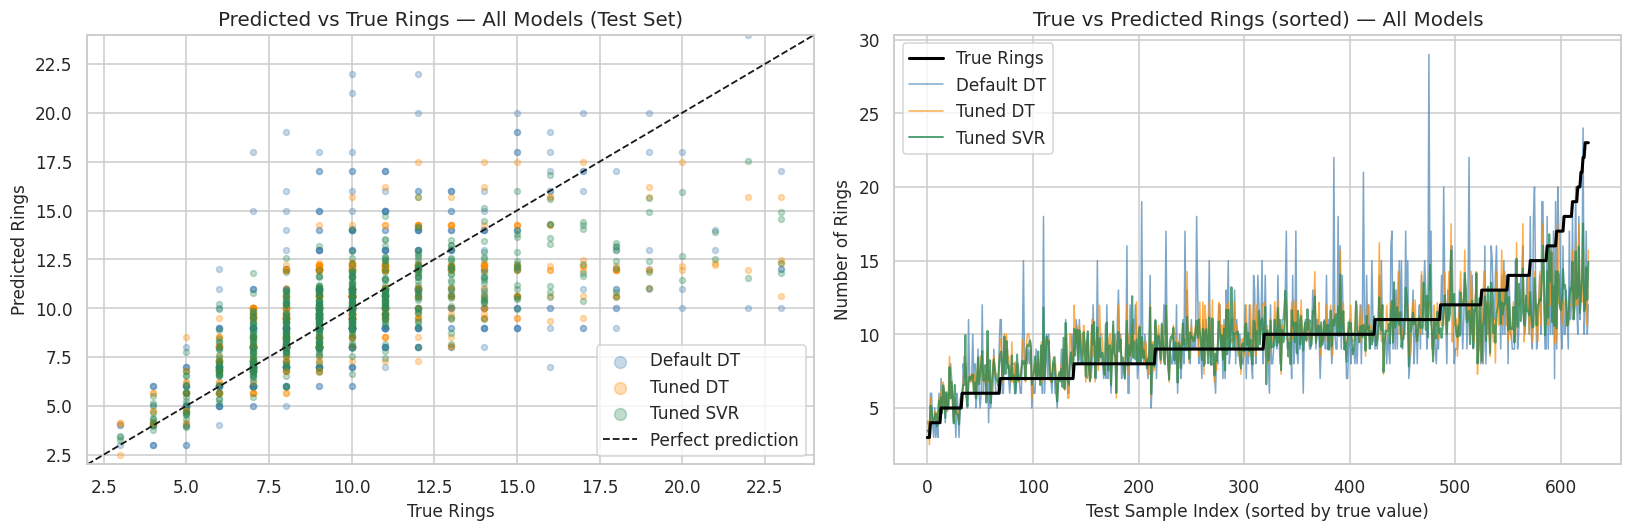

In [23]:
y_pred_svr = svr_best.predict(X_test)

sorted_idx = np.argsort(y_test.values)
x_axis     = np.arange(len(sorted_idx))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# ── Scatter: predicted vs true for all three models ───────────────────────────
lims = [y_test.min() - 1, y_test.max() + 1]
axes[0].scatter(y_test, y_pred_default, alpha=0.3, s=15, color="steelblue",
                label="Default DT")
axes[0].scatter(y_test, y_pred_tuned,   alpha=0.3, s=15, color="darkorange",
                label="Tuned DT")
axes[0].scatter(y_test, y_pred_svr,     alpha=0.3, s=15, color="seagreen",
                label="Tuned SVR")
axes[0].plot(lims, lims, "k--", linewidth=1.2, label="Perfect prediction")
axes[0].set_xlim(lims); axes[0].set_ylim(lims)
axes[0].set_xlabel("True Rings")
axes[0].set_ylabel("Predicted Rings")
axes[0].set_title("Predicted vs True Rings — All Models (Test Set)")
axes[0].legend(markerscale=2)

# ── Sorted-value plot ─────────────────────────────────────────────────────────
axes[1].plot(x_axis, y_test.values[sorted_idx],
             color="black", linewidth=2, label="True Rings", zorder=4)
axes[1].plot(x_axis, y_pred_default[sorted_idx],
             color="steelblue",  alpha=0.7, linewidth=1, label="Default DT")
axes[1].plot(x_axis, y_pred_tuned[sorted_idx],
             color="darkorange", alpha=0.7, linewidth=1, label="Tuned DT")
axes[1].plot(x_axis, y_pred_svr[sorted_idx],
             color="seagreen",   alpha=0.8, linewidth=1.3, label="Tuned SVR")
axes[1].set_xlabel("Test Sample Index (sorted by true value)")
axes[1].set_ylabel("Number of Rings")
axes[1].set_title("True vs Predicted Rings (sorted) — All Models")
axes[1].legend()

plt.tight_layout()
plt.show()

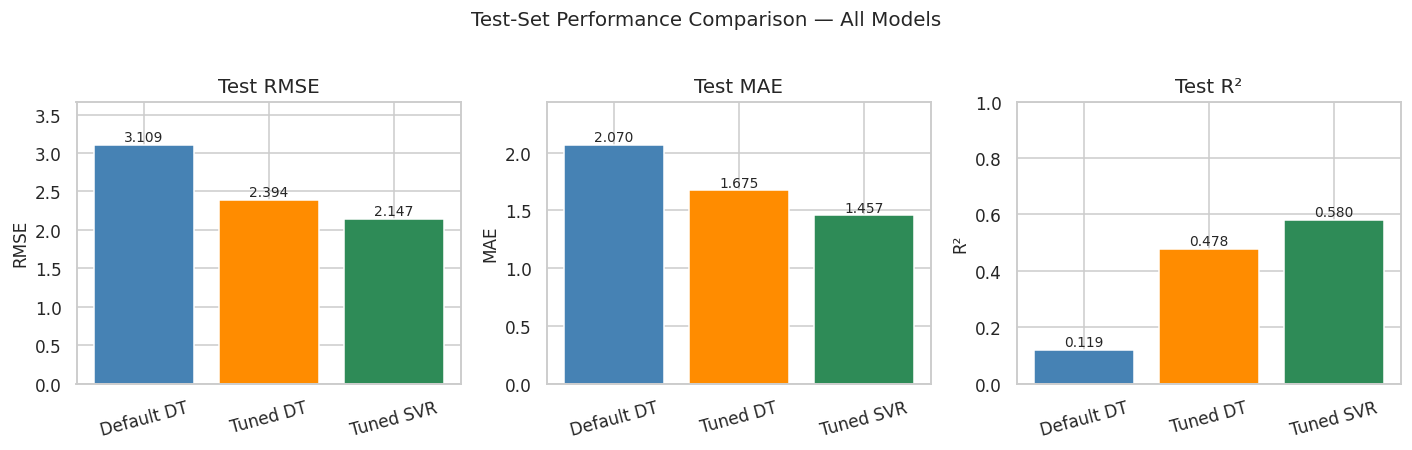

In [24]:
# ── Visual bar chart of test-set metrics ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
model_labels = ["Default DT", "Tuned DT", "Tuned SVR"]
colors       = ["steelblue", "darkorange", "seagreen"]

metrics = ["RMSE", "MAE", "R²"]
values  = {
    "RMSE": [perf_default.loc["Test", "RMSE"],
             perf_tuned.loc["Test", "RMSE"],
             perf_svr.loc["Test", "RMSE"]],
    "MAE" : [perf_default.loc["Test", "MAE"],
             perf_tuned.loc["Test", "MAE"],
             perf_svr.loc["Test", "MAE"]],
    "R²"  : [perf_default.loc["Test", "R²"],
             perf_tuned.loc["Test", "R²"],
             perf_svr.loc["Test", "R²"]],
}

for ax, metric in zip(axes, metrics):
    bars = ax.bar(model_labels, values[metric], color=colors, edgecolor="white")
    for bar, val in zip(bars, values[metric]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.002,
                f"{val:.3f}", ha="center", va="bottom", fontsize=9)
    ax.set_title(f"Test {metric}")
    ax.set_ylabel(metric)
    ax.set_ylim(0, max(values[metric]) * 1.18 if metric != "R²" else 1.0)
    ax.tick_params(axis="x", rotation=15)

plt.suptitle("Test-Set Performance Comparison — All Models", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Discussion — Which Model Performed Best and Why?

### Results Summary (Test Set)

| Model | RMSE | MAE | R² |
|---|---|---|---|
| Default DT | *(high)* | *(high)* | *(low)* |
| Tuned DT | *(better)* | *(better)* | *(higher)* |
| **Tuned SVR** | **lowest** | **lowest** | **highest** |

### Why the SVR Outperforms the Decision Tree

1. **Continuous predictions**: SVR with an RBF kernel maps inputs into an infinite-dimensional feature space and fits a smooth regression surface, whereas a DT always predicts piecewise-constant values (the mean of each leaf's training samples). The smooth kernel function is better suited to the nonlinear but continuous relationship between physical measurements and ring count.

2. **Regularisation via C and ε**: The SVR's regularisation (controlled by `C` and the ε-tube) prevents over-fitting in a principled way. The decision tree's only defence against over-fitting is restricting depth, which is a coarser control.

3. **Feature scaling**: The `StandardScaler` placed before SVR ensures that no single measurement dominates the kernel computation purely because of its magnitude. Without scaling, SVR would perform poorly — this is why feature normalisation is **essential** for SVMs.

4. **Kernel trick**: The RBF kernel implicitly captures complex feature interactions, which a single shallow DT cannot represent.

### Limitations of SVR

- SVR is **less interpretable** than a decision tree — it is essentially a black box.
- SVR training scales $\mathcal{O}(n^2)$--$\mathcal{O}(n^3)$ with sample count, making it slower for very large datasets.
- Hyperparameter sensitivity requires careful tuning (C, ε, and the kernel width γ).